# Learning a 3-channel selector for lentils (Gumbel-Softmax + AdaCLIP)

Hyperspectral cameras measure many bands (61 for the Ultris XMR lentils dataset), but most
vision anomaly detectors want a 3-channel image. Which three bands should represent the cube?

This tutorial recreates how the lentils whitepaper answered that: a **ConcreteChannelMixer**
(Gumbel-Softmax / Concrete relaxation) learns a hard 61 -> 3 band selection by
backpropagating an IoU loss **through a frozen AdaCLIP detector** on the original lentils
train split. At the end the notebook prints the three selected band indices and their
wavelengths - on the published full run the selector converged to indices **[14, 59, 57]**,
i.e. **542 / 902 / 886 nm**, the "custom selector" used by the champion Dinomaly pipeline.

The story in five steps:
1. provision the original dataset + datasplit (HuggingFace, cu3s -> per-frame NPZ),
2. wire the pipeline explicitly (data -> normalizer -> concrete selector -> AdaCLIP),
3. add the two losses (IoU supervision + selector distinctness repulsion) and metrics,
4. train **only the selector** (AdaCLIP and everything else stay frozen),
5. read the three winning channels off the selector and hand them to downstream pipelines.


In [1]:
# Colab bootstrap: install the packages when running in Colab; a no-op locally.
try:
    import cuvis_ai, cuvis_ai_adaclip, cuvis_ai_dataloader  # noqa: F401
except ImportError:
    %pip install -q cuvis-ai \
        "cuvis-ai-adaclip @ git+https://github.com/cubert-hyperspectral/cuvis-ai-adaclip.git@v0.3.1" \
        "cuvis-ai-dataloader[cu3s,coco] @ git+https://github.com/cubert-hyperspectral/cuvis-ai-dataloader.git@v0.6.0"


/mnt/data/anish/lentils_trainday/cuvis-ai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline
from __future__ import annotations

import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from loguru import logger

logger.remove()
logger.add(sys.stderr, level="INFO")

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {device}")


device: cuda


## 1 - Knobs

One cell with everything you may want to change. The defaults are the **whitepaper recipe**
(full 808-frame train split, 20 epochs) - the setting that actually converges to the
published bands, and what the baked outputs below were produced with. It is a long run
(several hours on a single 24 GB GPU, ~14 GB peak). For a quick dry-run that executes end
to end in minutes, set `MAX_EPOCHS = 1` and `CONVERT_LIMIT = 24` (the band pick is then
meaningless - too few frames / one tau step).


In [3]:
DATA_DIR = Path("data")            # dataset download root (cwd-relative)
NPZ_DIR = Path("data_npz")         # converted per-frame NPZ + universe.csv + splits.json
MAX_EPOCHS = 20                    # whitepaper recipe; drives the Gumbel tau anneal. dry-run: 1
CONVERT_LIMIT = 0                  # 0 = all frames (full split). dry-run: e.g. 24 per split
BATCH_SIZE = 1
SEED = 42
RUN_VAL_EVAL = True                # quick validation pass after training


## 2 - The original dataset and datasplit

`cubert-gmbh/XMR_Industrial_Foreign_Object_Detection_Lentils`: 1136 frames (61 bands,
430-910 nm), 8 semantic classes (0 = background/normal, 1-7 = foreign-object categories),
and the official `splits.csv` datasplit - train 808 (500 annotated + 308 normal),
val 148, test 180. Frames come in groups of four lighting variants that always share a
split.

Provisioning is the standard two lines: download the dataset once, then convert the split
manifest to per-frame NPZ plus the `universe.csv` / `splits.json` pair the data module
consumes. The conversion reads cu3s, so it needs the `cuvis-ai-dataloader[cu3s]` extra
(installed in the bootstrap cell).


In [4]:
from cuvis_ai_core.data.public_datasets import PublicDatasets
from cuvis_ai_dataloader.data.npz_converter import convert_split_manifest

PublicDatasets.download_dataset("Industrial_FOD_Lentils", download_path=str(DATA_DIR), force=False)
raw_dir = DATA_DIR / "XMR_Industrial_Foreign_Object_Detection_Lentils"

universe_csv = NPZ_DIR / "universe.csv"
splits_json = NPZ_DIR / "splits.json"
result = convert_split_manifest(
    raw_dir / "splits.csv", raw_dir, NPZ_DIR,
    universe_csv=universe_csv, splits_json=splits_json,
    limit=CONVERT_LIMIT,
)
print(result)


2026-08-27 11:08:31.766 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_11-11-01.cu3s -> 2 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-27 11:08:31.769 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_11-31-31.cu3s -> 17 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-27 11:08:31.788 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_11-38-39.cu3s -> 81 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-27 11:08:31.819 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_13-58-04_1.cu3s -> 96 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-27 11:08:31.866 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_13-58-04_2.cu3s -> 136 frame(s) into data_npz (all reused, cu3s not opened)


...

2026-08-27 11:08:32.106 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_17_11-11-50.cu3s -> 80 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-27 11:08:32.134 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_17_11-41-54.cu3s -> 80 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-27 11:08:32.168 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_17_14-38-58.cu3s -> 100 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-27 11:08:32.175 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_split_manifest:431 - convert_split_manifest: 1136 frame(s), 15 session(s) -> data_npz/universe.csv + data_npz/splits.json


SplitManifestOutputs(splits_json=PosixPath('data_npz/splits.json'), universe_csv=PosixPath('data_npz/universe.csv'))


In [5]:
# Per-channel wavelengths, read once from the first converted frame (all cubes share them).
# universe.csv stores `materialized_path` relative to its own directory, so resolve there.
with open(universe_csv, newline="", encoding="utf-8") as fh:
    first_row = next(csv.DictReader(fh))
first_npz = (universe_csv.parent / first_row["materialized_path"]).resolve()
wavelengths = np.load(first_npz, allow_pickle=True)["wavelengths"].astype(float).ravel()
print(f"{wavelengths.size} bands, {wavelengths.min():.0f}-{wavelengths.max():.0f} nm")


61 bands, 430-910 nm


## 3 - The pipeline, node by node

- **AnomalyDataNode** adapts each batch: `cube [B,H,W,61]`, binary `mask` (any class > 0 is
  a foreign object), `wavelengths`.
- **MinMaxNormalizer** learns global min/max over the train stream (statistical phase).
- **ConcreteChannelMixer** is the lesson: per output channel c it keeps logits over the 61
  input bands and samples `softmax((logits_c + Gumbel)/tau)` during training. `tau` anneals
  `10.0 -> 0.1` across `MAX_EPOCHS`, so the soft mixture hardens into a (near) one-hot pick;
  at val/test it uses the hard `argmax` bands (`use_hard_inference=True`).
- **AdaCLIPDetector** (frozen, `enable_gradients=True`) turns the selected 3-channel image
  into pixel anomaly scores; gradients flow *through* it into the selector logits only.
- **IoULoss** supervises those scores against the ground-truth masks; **DistinctnessLoss**
  (weight 0.1) repels the three channels from collapsing onto the same band.
- **TwoStageBinaryDecider + AnomalyDetectionMetrics** report IoU/precision/recall during
  val; **ScoreHeatmapVisualizer + TensorBoardMonitorNode** log score maps per epoch.


In [6]:
from cuvis_ai.node.anomaly_visualization import ScoreHeatmapVisualizer
from cuvis_ai.node.channel_mixer import ConcreteChannelMixer
from cuvis_ai.node.data import AnomalyDataNode
from cuvis_ai.node.deciders.two_stage_decider import TwoStageBinaryDecider
from cuvis_ai.node.losses import DistinctnessLoss, IoULoss
from cuvis_ai.node.metrics import AnomalyDetectionMetrics
from cuvis_ai.node.monitor import TensorBoardMonitorNode
from cuvis_ai.node.normalization import MinMaxNormalizer
from cuvis_ai_adaclip.node.adaclip_node import AdaCLIPDetector

anomaly_data = AnomalyDataNode(normal_class_ids=[0], name="anomaly_data")
normalizer = MinMaxNormalizer(eps=1e-6, use_running_stats=True, name="MinMaxNormalizer")
concrete_selector = ConcreteChannelMixer(
    input_channels=61,
    output_channels=3,
    tau_start=10.0,
    tau_end=0.1,
    max_epochs=MAX_EPOCHS,     # the tau anneal spans the whole training run
    use_hard_inference=True,
    name="concrete_selector",
)
adaclip = AdaCLIPDetector(
    weight_name="pretrained_all",
    backbone="ViT-L-14-336",
    prompt_text="",
    image_size=518,
    prompting_depth=4,
    prompting_length=5,
    gaussian_sigma=4.0,
    use_half_precision=False,
    enable_warmup=False,
    enable_gradients=True,     # frozen weights, but gradients must flow through to the selector
    use_torch_preprocess=True,
    name="adaclip",
)
iou_loss = IoULoss(weight=1.0, smooth=1e-6, normalize_method="minmax", name="iou_loss")
distinctness_loss = DistinctnessLoss(weight=0.1, name="distinctness_loss")
decider = TwoStageBinaryDecider(
    image_threshold=0.24, top_k_fraction=0.001, quantile=0.995, name="decider"
)
metrics_anomaly = AnomalyDetectionMetrics(name="metrics_anomaly")
score_heatmap = ScoreHeatmapVisualizer(normalize_scores=True, cmap="inferno", up_to=3, name="score_heatmap")
tensorboard = TensorBoardMonitorNode(
    output_dir="outputs/channel_selector/tensorboard",
    run_name="concrete_adaclip_lentils",
    name="TensorBoardMonitorNode",
)


2026-08-27 11:08:32.318 | WARNING  | cuvis_ai.node.monitor:_resolve_log_dir:141 - Run directory 'concrete_adaclip_lentils' already exists. Using 'concrete_adaclip_lentils_v4' instead.


2026-08-27 11:08:32.319 | INFO     | cuvis_ai.node.monitor:__init__:117 - TensorBoard writer initialized: outputs/channel_selector/tensorboard/concrete_adaclip_lentils_v4


2026-08-27 11:08:32.320 | INFO     | cuvis_ai.node.monitor:__init__:118 - To view visualizations, run: uv run tensorboard --logdir=outputs/channel_selector/tensorboard


In [7]:
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline

pipeline = CuvisPipeline("concrete_adaclip_lentils")

pipeline.connect(anomaly_data.outputs.cube, normalizer.inputs.data)
pipeline.connect(normalizer.outputs.normalized, concrete_selector.inputs.data)
pipeline.connect(concrete_selector.outputs.rgb, adaclip.inputs.rgb_image)

pipeline.connect(adaclip.outputs.scores, iou_loss.inputs.predictions)
pipeline.connect(anomaly_data.outputs.mask, iou_loss.inputs.targets)
pipeline.connect(concrete_selector.outputs.selection_weights, distinctness_loss.inputs.selection_weights)

pipeline.connect(adaclip.outputs.scores, decider.inputs.logits)
pipeline.connect(adaclip.outputs.scores, metrics_anomaly.inputs.logits)
pipeline.connect(anomaly_data.outputs.mask, metrics_anomaly.inputs.targets)
pipeline.connect(decider.outputs.decisions, metrics_anomaly.inputs.decisions)

pipeline.connect(adaclip.outputs.scores, score_heatmap.inputs.scores)
pipeline.connect(metrics_anomaly.outputs.metrics, tensorboard.inputs.metrics)
pipeline.connect(score_heatmap.outputs.artifacts, tensorboard.inputs.artifacts)

pipeline.to(device)
pipeline


concrete_adaclip_lentils:
AnomalyDataNode(
  (_binary_mapper): BinaryAnomalyLabelMapper()
)
MinMaxNormalizer()
ConcreteChannelMixer()
AdaCLIPDetector()
IoULoss()
DistinctnessLoss()
TwoStageBinaryDecider()
AnomalyDetectionMetrics(
  (precision_metric): BinaryPrecision()
  (recall_metric): BinaryRecall()
  (f1_metric): BinaryF1Score()
  (iou_metric): BinaryJaccardIndex()
  (average_precision_metric): BinaryAveragePrecision()
)
ScoreHeatmapVisualizer()
TensorBoardMonitorNode()
Use `pipeline.visualize()` for Graphviz/Mermaid output.

## 4 - Data module and the two training phases

`npz_multi` serves the converted frames through the frozen `splits.json` selectors, so the
run uses exactly the original datasplit. Training is the usual two-phase Cuvis.AI story:
the **StatisticalTrainer** fits data-derived state (the normalizer bounds) from the train
stream, then the **GradientTrainer** optimizes - after unfreezing **only** the selector.
The recipe mirrors the original trainrun: AdamW lr 1e-3 / weight-decay 0.01,
reduce-on-plateau on `metrics_anomaly/iou`, gradient clip 1.0.


In [8]:
from cuvis_ai_core.training import GradientTrainer, StatisticalTrainer
from cuvis_ai_core.training.config import TrainingConfig
from cuvis_ai_dataloader.data.datamodule_npz_multi import MultiNpzDataModule
from cuvis_ai_schemas.training.data import DataSplitConfig

datamodule = MultiNpzDataModule(
    splits=DataSplitConfig(splits_path=str(splits_json)),
    universe_csv=str(universe_csv),
    batch_size=BATCH_SIZE,
    num_workers=0,
)

StatisticalTrainer(pipeline=pipeline, datamodule=datamodule).fit()

pipeline.unfreeze_nodes_by_name(["concrete_selector"])  # everything else stays frozen

training_config = TrainingConfig.model_validate({
    "seed": SEED,
    "max_epochs": MAX_EPOCHS,
    "accelerator": "auto",
    "devices": 1,
    "default_root_dir": "outputs/channel_selector",
    "precision": "32-true",
    "log_every_n_steps": 10,
    "check_val_every_n_epoch": 1,
    "gradient_clip_val": 1.0,
    "optimizer": {"name": "adamw", "lr": 1e-3, "weight_decay": 0.01, "betas": [0.9, 0.999]},
    "scheduler": {
        "name": "reduce_on_plateau", "monitor": "metrics_anomaly/iou", "mode": "max",
        "factor": 0.5, "patience": 5, "min_lr": 1e-6,
    },
})
trainer = GradientTrainer(
    pipeline=pipeline,
    datamodule=datamodule,
    loss_nodes=[iou_loss, distinctness_loss],
    metric_nodes=[metrics_anomaly],
    training_config=training_config,
)
trainer.fit()


2026-08-27 11:08:32.517 | INFO     | cuvis_ai_core.training.trainers:fit:559 - Training 1 statistical nodes...


2026-08-27 11:08:32.518 | INFO     | cuvis_ai_core.training.trainers:fit:567 -   Training MinMaxNormalizer...


Seed set to 42


2026-08-27 11:21:44.208 | INFO     | cuvis_ai_core.training.trainers:fit:148 - ============================================================


2026-08-27 11:21:44.208 | INFO     | cuvis_ai_core.training.trainers:fit:149 - Training: max_epochs=20, optimizer=adamw(lr=0.001)


...

2026-08-27 18:10:34.143 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.141s (141.5ms), batch_size=1, per_image=141.5ms


2026-08-27 18:10:35.329 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.141s (141.3ms), batch_size=1, per_image=141.3ms


2026-08-27 18:10:36.524 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.142s (142.3ms), batch_size=1, per_image=142.3ms


2026-08-27 18:10:37.660 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.143s (143.2ms), batch_size=1, per_image=143.2ms


`Trainer.fit` stopped: `max_epochs=20` reached.


## 5 - The three selected channels

The payoff: the selector's logits, hardened by the tau anneal, name three bands. On the
published whitepaper run (full split, 20 epochs) they converged to **indices [14, 59, 57]
= 542 / 902 / 886 nm** - one green band plus two near-infrared bands, which became the
fixed "custom selector" of the champion Dinomaly pipeline.


In [9]:
bands = concrete_selector.get_selected_bands().tolist()
band_nm = [float(wavelengths[b]) for b in bands]

print("Selected band indices (channel 1, 2, 3):", bands)
print("Selected wavelengths [nm]:            ", [round(w, 1) for w in band_nm])
print()
print("Hint: reuse these three wavelengths as a fixed selector in any 3-channel pipeline,")
print("e.g. for the Dinomaly foreign-object detector:")
print()
print("    FixedWavelengthSelector(")
print(f"        target_wavelengths={[round(w, 1) for w in band_nm]},")
print("        normalize_output=True, apply_gamma=True,")
print("    )")
print()
print("Published full-split run: indices [14, 59, 57] = 542 / 902 / 886 nm. The selection")
print("depends on the data, the epochs (tau anneal), and the seed - a smoke run or another")
print("seed can land on neighbouring bands; spectrally close picks are equally usable.")


Selected band indices (channel 1, 2, 3): [40, 59, 57]
Selected wavelengths [nm]:             [750.0, 902.0, 886.0]

Hint: reuse these three wavelengths as a fixed selector in any 3-channel pipeline,
e.g. for the Dinomaly foreign-object detector:

    FixedWavelengthSelector(
        target_wavelengths=[750.0, 902.0, 886.0],
        normalize_output=True, apply_gamma=True,
    )

Published full-split run: indices [14, 59, 57] = 542 / 902 / 886 nm. The selection
depends on the data, the epochs (tau anneal), and the seed - a smoke run or another
seed can land on neighbouring bands; spectrally close picks are equally usable.


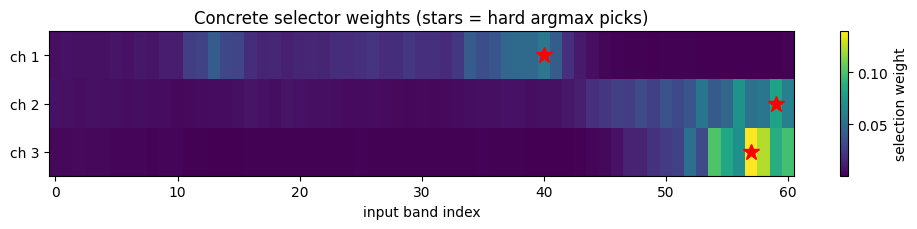

In [10]:
# The full selection-weight matrix: rows = output channels, columns = the 61 input bands.
weights = concrete_selector.get_selection_weights(deterministic=True).detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 2.4))
im = ax.imshow(weights, aspect="auto", cmap="viridis")
ax.set_yticks(range(weights.shape[0]), [f"ch {i + 1}" for i in range(weights.shape[0])])
ax.set_xlabel("input band index")
for row, b in enumerate(bands):
    ax.plot(b, row, "r*", markersize=12)
fig.colorbar(im, ax=ax, label="selection weight")
ax.set_title("Concrete selector weights (stars = hard argmax picks)")
plt.tight_layout()
plt.show()


## 6 - Sanity check on the validation split

The metric node already ran during training; a standalone validation pass prints the
val-split metrics for the trained selector (with hard band selection active).


In [11]:
if RUN_VAL_EVAL:
    val_metrics = trainer.validate()
    print(val_metrics)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/mnt/data/anish/lentils_trainday/cuvis-ai/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/mnt/data/anish/lentils_trainday/cuvis-ai/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


2026-08-27 18:10:39.699 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.142s (142.1ms), batch_size=1, per_image=142.1ms


2026-08-27 18:10:40.884 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.151s (151.2ms), batch_size=1, per_image=151.2ms


2026-08-27 18:10:42.117 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.141s (140.8ms), batch_size=1, per_image=140.8ms


...

2026-08-27 18:13:26.439 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.146s (145.7ms), batch_size=1, per_image=145.7ms


2026-08-27 18:13:27.588 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.142s (142.2ms), batch_size=1, per_image=142.2ms


2026-08-27 18:13:28.735 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.136s (136.4ms), batch_size=1, per_image=136.4ms


2026-08-27 18:13:29.840 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.142s (141.7ms), batch_size=1, per_image=141.7ms


[{'val/iou_loss': 0.8661750555038452, 'val/distinctness_loss': nan, 'val_loss': nan, 'metrics_anomaly/precision': 0.09318094700574875, 'metrics_anomaly/recall': 0.32190844416618347, 'metrics_anomaly/f1_score': 0.1312635838985443, 'metrics_anomaly/iou': 0.08267257362604141, 'metrics_anomaly/average_precision': 0.37793490290641785}]


## 7 - Where to go from here

- Drop the printed wavelengths into a `FixedWavelengthSelector` and train a normal-only
  **Dinomaly** pipeline on them (see `configs/pipeline/anomaly/dinomaly/dinomaly_cir.yaml`
  for the template - swap the CIR wavelengths for yours).
- A fixed 3-band representation is also a deployment story: a 3-filter multispectral
  sensor could replace the full hyperspectral acquisition for this task.
- Reproduction notes: the whitepaper-scale run is `MAX_EPOCHS = 20`, `CONVERT_LIMIT = 0`
  (full 808-frame train split) - several hours on one 24 GB GPU. Band picks are
  seed-sensitive within spectrally similar neighbours; the demo-scale dataset converges to
  different bands than the full split, so use the full split when you want the published
  542 / 902 / 886 nm.
